<a href="https://colab.research.google.com/github/carlosrabazo/THE_CORE/blob/main/practica_mineria_videojuegos_alumnos_guiada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica guiada de Minería de Datos para Ingeniería de Videojuegos

## Caso práctico
Trabajas en el equipo de **Game Analytics** de un estudio que gestiona un videojuego online multijugador.
Dispones de un dataset con telemetría agregada de jugadores y debes analizarlo para encontrar patrones de comportamiento y construir un modelo sencillo de **churn**.

## Qué se trabaja en esta práctica
- Comprensión del problema
- Calidad de datos
- Limpieza y transformación
- Exploración visual
- Reducción de dimensionalidad con **PCA**
- Modelo base de clasificación

## Instrucciones
- En algunas celdas ya tienes parte del código hecha.
- Tendrás que completar las zonas marcadas con `# TODO`.
- No se trata solo de ejecutar: **interpreta** lo que ves.


## 1. Importación de librerías

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

plt.figure(figsize=(8,5))
pd.set_option('display.max_columns', None)

<Figure size 800x500 with 0 Axes>

## 2. Carga del dataset

In [7]:
# El archivo debe estar en la misma carpeta que este notebook.

ruta = 'videojuegos_online_telemetria.csv'

# TODO: carga el CSV en un DataFrame llamado df
df = pd.read_csv(ruta)

# TODO: muestra las 5 primeras filas
display(df.head())

,PlayerID,Age,Region,Platform,PreferredGenre,SessionsPerWeek,AvgSessionMinutes,DaysSinceLastLogin,PlayerLevel,MatchesPlayedLast30D,WinRate,InGamePurchase,FriendsInGame,UsesVoiceChat,AchievementsUnlocked,ReportsReceivedLast30D,Churn30D
0,P0001,22.0,LATAM,PC,RPG,3,87.0,11,59,14,0.481,7.38,3.0,1,17,0,0
1,P0002,21.0,EU,PC,Shooter,7,113.0,0,45,24,0.475,11.56,8.0,1,21,2,0
2,P0003,40.0,LATAM,Mobile,Shooter,3,67.0,3,68,27,0.341,0.42,6.0,1,26,1,0
3,P0004,37.0,NaN,PC,Shooter,0,48.0,9,40,39,0.225,8.83,NaN,1,41,2,0
4,P0005,28.0,EU,Console,Shooter,3,90.0,15,51,15,0.454,23.86,0.0,0,35,1,1


### Preguntas rápidas
1. ¿Qué representa cada fila?
2. ¿Qué variable parece ser la variable objetivo?
3. ¿Qué decisiones de producto o diseño podría apoyar este análisis?


## 3. Comprensión inicial del dataset

In [8]:
print('Dimensiones del dataset:', df.shape)
print('\nTipos de datos:')
display(df.dtypes)

print('\nResumen estadístico de variables numéricas:')
display(df.describe())


Dimensiones del dataset: (558, 17)

Tipos de datos:


,0
PlayerID,object
Age,float64
Region,object
Platform,object
PreferredGenre,object
SessionsPerWeek,int64
AvgSessionMinutes,float64
DaysSinceLastLogin,int64
PlayerLevel,int64
MatchesPlayedLast30D,int64



Resumen estadístico de variables numéricas:


,Age,SessionsPerWeek,AvgSessionMinutes,DaysSinceLastLogin,PlayerLevel,MatchesPlayedLast30D,WinRate,InGamePurchase,FriendsInGame,UsesVoiceChat,AchievementsUnlocked,ReportsReceivedLast30D,Churn30D
count,546.000000,558.000000,546.000000,558.000000,558.000000,558.000000,546.000000,546.000000,546.000000,558.000000,558.000000,558.000000,558.000000
mean,27.893773,4.500000,78.578755,7.646953,35.127240,27.048387,0.512256,14.318462,7.569597,0.546595,22.206093,1.080645,0.408602
std,7.256991,1.909769,41.368230,5.911898,17.631983,14.633996,0.155886,47.664126,4.732448,0.498271,11.713309,1.083060,0.492017
min,16.000000,0.000000,10.000000,0.000000,1.000000,0.000000,0.123000,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,21.000000,3.000000,60.000000,3.000000,23.000000,17.000000,0.409000,3.252500,4.000000,0.000000,14.000000,0.000000,0.000000
50%,28.000000,4.000000,76.000000,7.000000,36.000000,27.000000,0.512500,8.050000,7.000000,1.000000,22.000000,1.000000,0.000000
75%,34.000000,6.000000,93.000000,11.000000,47.000000,37.000000,0.619000,16.750000,11.000000,1.000000,30.000000,2.000000,1.000000
max,40.000000,10.000000,600.000000,26.000000,86.000000,69.000000,0.950000,999.000000,25.000000,1.000000,61.000000,5.000000,1.000000


## 4. Calidad del dato

In [10]:
print('Valores nulos por columna:')
display(df.isna().sum().sort_values(ascending=False))

print('Filas duplicadas:', df.duplicated().sum())


Valores nulos por columna:


,0
Region,130
InGamePurchase,12
Age,12
AvgSessionMinutes,12
WinRate,12
FriendsInGame,12
PlayerID,0
PreferredGenre,0
Platform,0
PlayerLevel,0


Filas duplicadas: 8


In [12]:
print('Valores únicos de Region:')
print(df['Region'].unique())

print('\nValores únicos de Platform:')
print(df['Platform'].unique())

print('\nValores únicos de PreferredGenre:')
print(df['PreferredGenre'].unique())

Valores únicos de Region:
['LATAM' 'EU' nan 'APAC' 'Europe']

Valores únicos de Platform:
['PC' 'Mobile' 'Console' 'pc']

Valores únicos de PreferredGenre:
['RPG' 'Shooter' 'Strategy' 'Battle Royale' 'MOBA' 'Sports']


### Pregunta
¿Detectas inconsistencias en variables categóricas? Escríbelas aquí:

*   **Region**: 'EU' y 'Europe' se refieren a la misma región.
*   **Platform**: 'PC' y 'pc' se refieren a la misma plataforma.

## 5. Limpieza de datos

In [13]:
df_clean = df.copy()

# Eliminamos duplicados
df_clean = df_clean.drop_duplicates()

# TODO: corrige categorías inconsistentes
# Ejemplos esperados:
# - 'pc' debe pasar a 'PC'
# - 'Europe' debe pasar a 'EU'
df_clean['Platform'] = df_clean['Platform'].replace('pc', 'PC')
df_clean['Region'] = df_clean['Region'].replace('Europe', 'EU')

print(df_clean.shape)

(550, 17)


In [16]:
# Imputación sencilla de nulos en variables numéricas con la mediana
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# TODO: comprueba que ya no queden nulos
print('Valores nulos por columna después de la limpieza:')
display(df_clean.isna().sum().sort_values(ascending=False))

Valores nulos por columna después de la limpieza:


,0
Region,129
PlayerID,0
Age,0
Platform,0
PreferredGenre,0
SessionsPerWeek,0
AvgSessionMinutes,0
DaysSinceLastLogin,0
PlayerLevel,0
MatchesPlayedLast30D,0


In [20]:
# Imputar nulos en la columna 'Region' con la moda
mode_region = df_clean['Region'].mode()[0]
df_clean['Region'] = df_clean['Region'].fillna(mode_region)

print('Valores nulos por columna después de imputar la Región:')
display(df_clean.isna().sum().sort_values(ascending=False))

Valores nulos por columna después de imputar la Región:


,0
PlayerID,0
Age,0
Region,0
Platform,0
PreferredGenre,0
SessionsPerWeek,0
AvgSessionMinutes,0
DaysSinceLastLogin,0
PlayerLevel,0
MatchesPlayedLast30D,0


### Reflexión
¿Por qué tiene sentido usar la **mediana** en vez de la media en algunas variables de telemetría?

## 6. Exploración visual

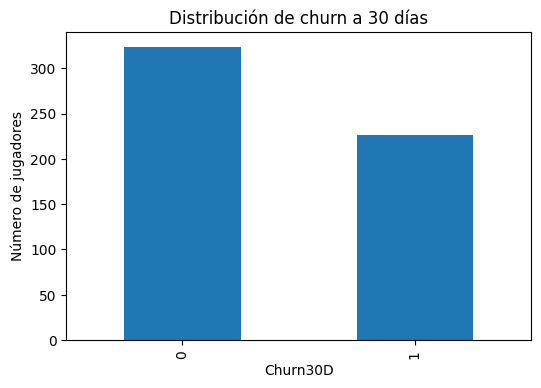

In [18]:
plt.figure(figsize=(6,4))
df_clean['Churn30D'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribución de churn a 30 días')
plt.xlabel('Churn30D')
plt.ylabel('Número de jugadores')
plt.show()


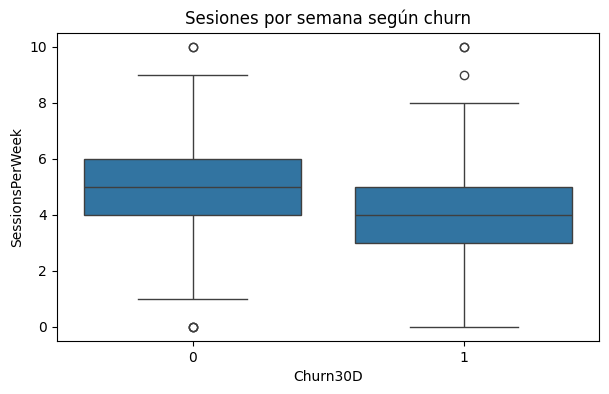

In [21]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df_clean, x='Churn30D', y='SessionsPerWeek')
plt.title('Sesiones por semana según churn')
plt.show()

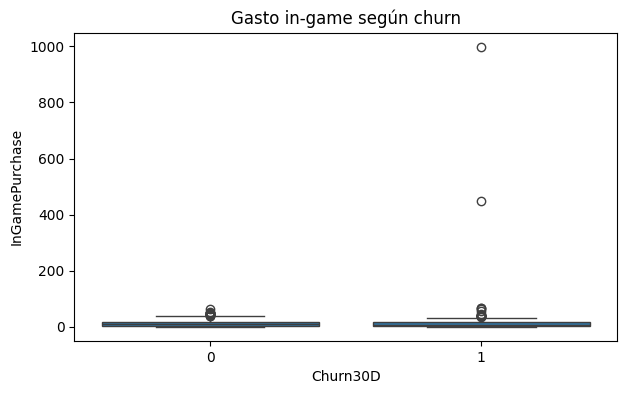

In [22]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df_clean, x='Churn30D', y='InGamePurchase')
plt.title('Gasto in-game según churn')
plt.show()


In [24]:
# TODO: calcula el churn medio por plataforma
# Pista: groupby + mean
churn_by_platform = df_clean.groupby('Platform')['Churn30D'].mean().reset_index()
display(churn_by_platform)

,Platform,Churn30D
0,Console,0.474684
1,Mobile,0.394231
2,PC,0.381944


### Preguntas de interpretación
Preguntas de interpretación
1. Basándonos en las visualizaciones y en el cálculo del churn por plataforma:
**¿Los jugadores con menos sesiones parecen abandonar más?**
Sí, el boxplot de 'SessionsPerWeek' por 'Churn30D' sugiere que los jugadores que abandonan ('Churn30D = 1') tienden a tener menos sesiones por semana en comparación con aquellos que no abandonan ('Churn30D = 0'). La mediana de SessionsPerWeek es notablemente menor para los jugadores que abandonan.

2. **¿Parece existir relación entre gasto y retención?**. Sí, el boxplot de 'InGamePurchase' por 'Churn30D' indica que existe una relación. Los jugadores que abandonan (Churn30D = 1) generalmente presentan menores cantidades de gasto dentro del juego que los jugadores retenidos (Churn30D = 0). Esto sugiere que un mayor gasto podría estar asociado con una mejor retención.

3. **¿Ves alguna señal útil para un equipo de LiveOps?**
Absolutamente. Hay varias señales útiles para un equipo de LiveOps:
- **Churn específico por plataforma**: Los jugadores de consola muestran la tasa de abandono más alta (alrededor del 47%), significativamente mayor que en PC o móvil. El equipo de LiveOps podría investigar problemas o experiencias específicas en la plataforma de consola que estén contribuyendo a este mayor churn.
- **Monitorización del engagement**: Los jugadores con menos sesiones semanales tienen más probabilidad de abandonar. LiveOps podría implementar sistemas para identificar jugadores con una frecuencia de sesiones decreciente y actuar de forma proactiva mediante incentivos o contenido personalizado.
- **Relación entre monetización y retención**: Un menor gasto dentro del juego está vinculado a un mayor churn. Esto sugiere que LiveOps debería fomentar dinámicas de engagement que conduzcan de forma natural al gasto, o bien ofrecer valor a jugadores con bajo gasto para mantenerlos activos, en lugar de centrarse únicamente en los grandes gastadores.

Estos insights pueden ayudar al equipo de LiveOps a priorizar sus esfuerzos y diseñar estrategias de retención más efectivas.

## 7. Preparación para modelado

In [25]:
y = df_clean['Churn30D']

# Quitamos la variable objetivo y el identificador
X = df_clean.drop(columns=['Churn30D', 'PlayerID'])

# Convertimos variables categóricas a numéricas
X = pd.get_dummies(X, drop_first=True)

print('Dimensiones de X:', X.shape)
display(X.head())


Dimensiones de X: (550, 21)


,Age,SessionsPerWeek,AvgSessionMinutes,DaysSinceLastLogin,PlayerLevel,MatchesPlayedLast30D,WinRate,InGamePurchase,FriendsInGame,UsesVoiceChat,AchievementsUnlocked,ReportsReceivedLast30D,Region_EU,Region_LATAM,Platform_Mobile,Platform_PC,PreferredGenre_MOBA,PreferredGenre_RPG,PreferredGenre_Shooter,PreferredGenre_Sports,PreferredGenre_Strategy
0,22.0,3,87.0,11,59,14,0.481,7.38,3.0,1,17,0,False,True,False,True,False,True,False,False,False
1,21.0,7,113.0,0,45,24,0.475,11.56,8.0,1,21,2,True,False,False,True,False,False,True,False,False
2,40.0,3,67.0,3,68,27,0.341,0.42,6.0,1,26,1,False,True,True,False,False,False,True,False,False
3,37.0,0,48.0,9,40,39,0.225,8.83,7.0,1,41,2,True,False,False,True,False,False,True,False,False
4,28.0,3,90.0,15,51,15,0.454,23.86,0.0,0,35,1,True,False,False,False,False,False,True,False,False


## 8. Estandarización y PCA

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

var_exp = pca_full.explained_variance_ratio_
var_exp_acum = np.cumsum(var_exp)

display(var_exp[:10])
display(var_exp_acum[:10])


In [ ]:
plt.figure(figsize=(8,4))
plt.plot(range(1, len(var_exp_acum)+1), var_exp_acum, marker='o')
plt.axhline(y=0.80, linestyle='--')
plt.axhline(y=0.90, linestyle='--')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('PCA - Varianza explicada acumulada')
plt.show()


In [ ]:
# TODO: crea un PCA de 2 componentes y transforma X_scaled


# TODO: crea un DataFrame llamado pca_df con columnas PC1 y PC2
# Añade también la columna Churn30D


In [ ]:
plt.figure(figsize=(8,5))
# TODO: crea un scatterplot de PC1 vs PC2 coloreado por Churn30D
# Pista: sns.scatterplot(...)

plt.title('Jugadores proyectados en 2 componentes principales')
plt.show()


### Preguntas de interpretación
1. ¿Se aprecia alguna separación visual entre perfiles?
2. ¿Qué ventaja aporta PCA en un problema con muchas variables?
3. ¿Qué inconveniente tiene usar PCA desde el punto de vista de interpretabilidad?


## 9. Modelo base de clasificación

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)


In [ ]:
modelo = LogisticRegression(max_iter=2000)
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)


In [ ]:
print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nClassification report:\n')
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print('Matriz de confusión:')
print(cm)


In [ ]:
# TODO: representa la matriz de confusión con un heatmap
# Pista: sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')



## 10. Conclusiones finales

Responde brevemente:

1. ¿Qué variables parecen más relacionadas con el churn?
2. ¿Qué acciones propondrías al equipo de diseño, retención o monetización?
3. ¿Qué has aprendido sobre preparación de datos y PCA en un contexto de videojuegos?
